# Threshold Tuning

Even a well-balanced model uses a default 0.5 threshold on P(Dead). By scanning
thresholds, we can trade precision for recall on the minority Dead class — the
key clinical lever after model selection.

## 1. Setup

In [1]:
import os
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

sys.path.insert(0, os.path.abspath('..'))

assert os.path.exists(os.path.join('..', 'data', 'Breast_Cancer.csv')), \
    "Dataset not found. Place Breast_Cancer.csv in the data/ folder."

from src.preprocessing import load_and_clean, split_features_target, get_train_test_split
from src.feature_engineering import add_features
from src.sampling import apply_sampler
from src.models import build_model, train_model
from src.evaluation import (
    get_all_metrics, apply_threshold, evaluate_model, load_results
)
from src import visualization

DATA_PATH = os.path.join('..', 'data', 'Breast_Cancer.csv')
FIGURES_DIR = os.path.join('..', 'results', 'figures')
METRICS_DIR = os.path.join('..', 'results', 'metrics')
os.makedirs(FIGURES_DIR, exist_ok=True)

df = load_and_clean(DATA_PATH)
df = add_features(df)
X, y = split_features_target(df)
X_train, X_test, y_train, y_test = get_train_test_split(X, y)

# Determine best model from notebook 02 by recall_dead
BEST_MODEL_TYPE = 'balanced_rf'
BEST_MODEL_NAME = 'Balanced RF'
algo_path = os.path.join(METRICS_DIR, 'algo_results.csv')
if os.path.exists(algo_path):
    algo_df = load_results(algo_path)
    best_row = algo_df.sort_values('recall_dead', ascending=False).iloc[0]
    name_map = {
        'Balanced RF': 'balanced_rf',
        'EasyEnsemble': 'easy_ensemble',
        'XGBoost': 'xgboost',
        'LightGBM': 'lightgbm',
    }
    BEST_MODEL_NAME = best_row['model_name']
    BEST_MODEL_TYPE = name_map.get(BEST_MODEL_NAME, 'balanced_rf')
    print(f'Best model from algo_results: {BEST_MODEL_NAME} (recall_dead={best_row["recall_dead"]})')
else:
    print('algo_results.csv not found — defaulting to Balanced RF')

print('=' * 60)
print(f'TRAINING: {BEST_MODEL_NAME}')
print('=' * 60)

best_model = None
try:
    if BEST_MODEL_TYPE == 'xgboost':
        ratio = (y_train == 1).sum() / (y_train == 0).sum()
        best_model = build_model('xgboost', scale_pos_weight=ratio)
        train_X, train_y = X_train, y_train
    else:
        best_model = build_model(BEST_MODEL_TYPE)
        train_X, train_y = X_train, y_train

    start = time.time()
    best_model = train_model(best_model, train_X, train_y)
    print(f'Trained in {time.time() - start:.1f}s')
except Exception as e:
    print(f'ERROR training best model: {e}')

Best model from algo_results: EasyEnsemble (recall_dead=1.0)
TRAINING: EasyEnsemble


Trained in 27.8s


## 2. Default threshold baseline

In [2]:
if best_model is not None:
    y_prob = best_model.predict_proba(X_test)[:, 1]
    y_pred_default = apply_threshold(y_prob, threshold=0.5)

    default_metrics = get_all_metrics(
        BEST_MODEL_NAME, y_test, y_pred_default, y_prob, threshold=0.5
    )
    print('Metrics at default threshold (0.5):')
    print(pd.Series(default_metrics))
    print('\nConfusion matrix:')
    print(confusion_matrix(y_test, y_pred_default, labels=[0, 1]))
    print(f"\nFalse negatives (Dead missed): {default_metrics['false_negatives']}")

Metrics at default threshold (0.5):
model_name                       EasyEnsemble
threshold                                 0.5
accuracy                               0.7068
recall_dead                            0.6341
precision_dead                           0.29
f1_dead                                 0.398
f2_dead                                0.5125
roc_auc                                0.7674
pr_auc                                 0.9456
false_negatives                            45
recall_alive                           0.7199
precision_alive                         0.916
f1_alive                               0.8062
timestamp          2026-06-16T12:28:13.584099
dtype: object

Confusion matrix:
[[ 78  45]
 [191 491]]

False negatives (Dead missed): 45


## 3. Threshold scan

In [3]:
from sklearn.metrics import precision_score, recall_score

if best_model is not None:
    thresholds = np.arange(0.05, 0.61, 0.01)
    scan_rows = []

    for t in thresholds:
        y_pred_t = apply_threshold(y_prob, threshold=t)
        rec = recall_score(y_test, y_pred_t, pos_label=0, zero_division=0)
        prec = precision_score(y_test, y_pred_t, pos_label=0, zero_division=0)
        f2 = (5 * prec * rec) / (4 * prec + rec) if (prec + rec) > 0 else 0
        cm = confusion_matrix(y_test, y_pred_t, labels=[0, 1])
        fn = int(cm[0, 1])
        scan_rows.append({
            'threshold': round(t, 2),
            'recall_dead': round(rec, 4),
            'precision_dead': round(prec, 4),
            'f2_dead': round(f2, 4),
            'false_negatives': fn,
        })

    scan_df = pd.DataFrame(scan_rows)
    best_idx = scan_df['f2_dead'].idxmax()
    optimal_threshold = scan_df.loc[best_idx, 'threshold']

    optimal_metrics = get_all_metrics(
        BEST_MODEL_NAME, y_test,
        apply_threshold(y_prob, optimal_threshold),
        y_prob, threshold=optimal_threshold
    )

    print(f'F2-optimal threshold: {optimal_threshold}')
    print('\n--- Default (0.5) vs F2-optimal ---')
    compare = pd.DataFrame([default_metrics, optimal_metrics]).set_index('model_name')
    print(compare[['threshold', 'recall_dead', 'precision_dead', 'f2_dead', 'false_negatives']])

F2-optimal threshold: 0.43

--- Default (0.5) vs F2-optimal ---
              threshold  recall_dead  precision_dead  f2_dead  false_negatives
model_name                                                                    
EasyEnsemble       0.50       0.6341          0.2900   0.5125               45
EasyEnsemble       0.43       0.9106          0.2244   0.5651               11


## 4. Threshold sensitivity chart

In [4]:
if best_model is not None:
    visualization.plot_threshold_sensitivity(
        BEST_MODEL_NAME, y_test, y_prob,
        save_path=os.path.join(FIGURES_DIR, '06_threshold_sensitivity.png')
    )
    print('Saved: results/figures/06_threshold_sensitivity.png')

Saved: results/figures/06_threshold_sensitivity.png


## 5. Final evaluation at optimal threshold

Full metrics at F2-optimal threshold:
model_name                       EasyEnsemble
threshold                                0.43
accuracy                               0.5056
recall_dead                            0.9106
precision_dead                         0.2244
f1_dead                                0.3601
f2_dead                                0.5651
roc_auc                                0.7674
pr_auc                                 0.9456
false_negatives                            11
recall_alive                           0.4326
precision_alive                        0.9641
f1_alive                               0.5972
timestamp          2026-06-16T12:28:14.362635
dtype: object

Classification report:
              precision    recall  f1-score   support

        Dead       0.22      0.91      0.36       123
       Alive       0.96      0.43      0.60       682

    accuracy                           0.51       805
   macro avg       0.59      0.67      0.48       805
weighted

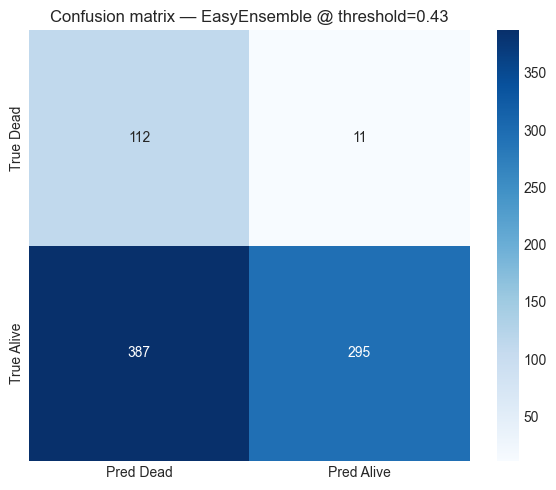

In [5]:
if best_model is not None:
    y_pred_optimal = apply_threshold(y_prob, threshold=optimal_threshold)

    print('Full metrics at F2-optimal threshold:')
    print(pd.Series(optimal_metrics))
    print('\nClassification report:')
    print(classification_report(
        y_test, y_pred_optimal, target_names=['Dead', 'Alive']
    ))

    plt.style.use('seaborn-v0_8-whitegrid')
    cm = confusion_matrix(y_test, y_pred_optimal, labels=[0, 1])
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Pred Dead', 'Pred Alive'],
        yticklabels=['True Dead', 'True Alive'], ax=ax
    )
    ax.set_title(f'Confusion matrix — {BEST_MODEL_NAME} @ threshold={optimal_threshold}')
    plt.tight_layout()
    plt.show()